In [1]:
import os
import pickle
import sys

import shap

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src import *

plt.rcParams.update({'font.size': 18})

# Explaining KAN With Shapley Value

The PyKAN trained in 3.1 is here loaded and explaining through the Shapley value technique.
Originating from game theory, the Shapley value is a powerful tool in the field of eXplainableAI. Through an iterative approximation, the features of the samples are randomly permuted and the distance in their prediction is used to understand how the model weights each of them to assert the engine's faulty state.

In [2]:
# 1s
train_x, train_y = read_dataset(stage='classification')
valid_x = read_dataset(stage='classification', dataset='valid')
test_x = read_dataset(stage='classification', dataset='test')

# Load the means and standard deviations of the train set used to train the model
norm = pd.read_csv('results/one_time_train_norm.csv').iloc[0]
means = norm[[f'{col}_mean' for col in train_x.columns]].values
stds = norm[[f'{col}_std' for col in train_x.columns]].values
means, stds = torch.tensor(means, dtype=torch.float32), torch.tensor(stds, dtype=torch.float32)

In [3]:
trainset_x = torch.tensor(train_x.values, dtype=torch.float32)
validset_x = torch.tensor(valid_x.values, dtype=torch.float32)
testset_x = torch.tensor(test_x.values, dtype=torch.float32)
trainset_x = (trainset_x - means) / stds
validset_x = (validset_x - means) / stds
testset_x = (testset_x - means) / stds

In [4]:
pyKAN: PHMNetwork = PyKAN([[len(train_x.columns), 0], [0, 1], [1, 0]], 'classification', device='cpu')

checkpoint directory created: ./model
saving model version 0.0


In [5]:
# 2s
pyKAN.load('fault_detection')
_, _, testset, _ = split_dataset(train_x, train_y['faulty'], train_ratio=0.15, standardize_y=False, max=1, seed=1)
metrics = pyKAN.test(testset)
assert metrics['avg_test_score'] > 0.8
pd.DataFrame([metrics])

100%|██████████| 39/39 [00:01<00:00, 25.93it/s]


,test_loss,avg_test_score,accuracy,precision,recall,f1,cm
0,0.123784,0.888776,0.964124,0.940312,0.972871,0.956315,"[[180357, 7867], [3456, 123936]]"


<Axes: ylabel='Frequency'>

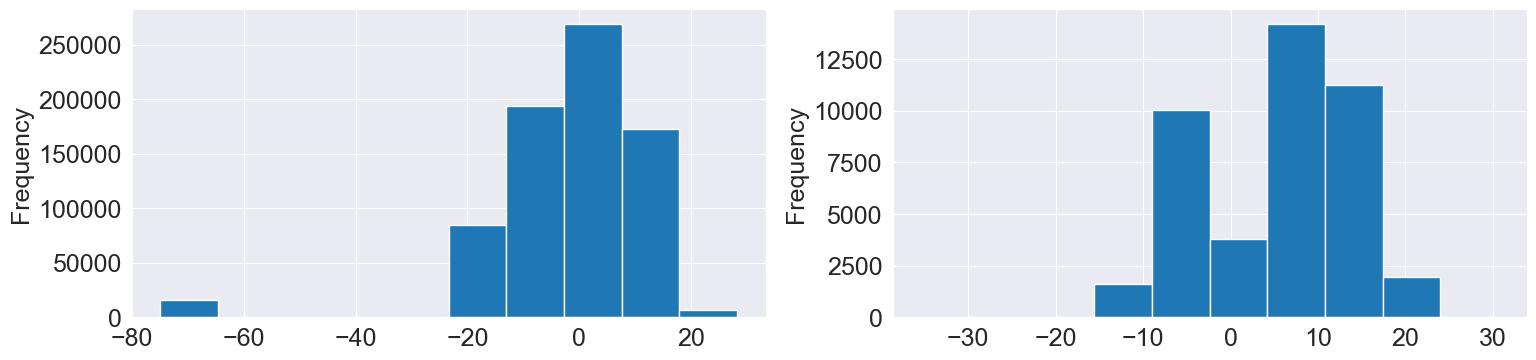

In [6]:
plt.figure(figsize=(18, 4))
plt.subplot(121)
train_x['trq_margin'].plot(kind='hist')
plt.subplot(122)
test_x['trq_margin'].plot(kind='hist')

In [7]:
def explain_with_shap(tag: str, dataset, samples=1000):
    def model_predict(x):
        with torch.no_grad():
            x = torch.tensor(x, dtype=torch.float32)
            return pyKAN(x).numpy()

    random_indices = np.random.choice(len(dataset), size=samples, replace=False)
    random_samples = pd.DataFrame(dataset[random_indices], columns=train_x.columns)
    explainer = shap.Explainer(model_predict, random_samples.values)
    shap_values = explainer(random_samples.values)
    with open(f'{tag}_shapley.pkl', 'wb') as f:
        pickle.dump(shap_values, f)
    shap.summary_plot(shap_values.values, random_samples, plot_size=[18, 10], show=False)
    plt.savefig(f'img/{tag}_shapley.png', bbox_inches='tight', dpi=300)
    plt.close()

If the cell below takes too much time, feel free to reduce the number of samples to a lower value, say, 500.

Please note that the Shapley value is a method to understand the model's judgement, therefore, it matters not whether we get samples from the train or test set to compute it. If you prefer to use the test set, simply uncomment the second line.

ExactExplainer explainer: 1001it [04:03,  3.93it/s]                          


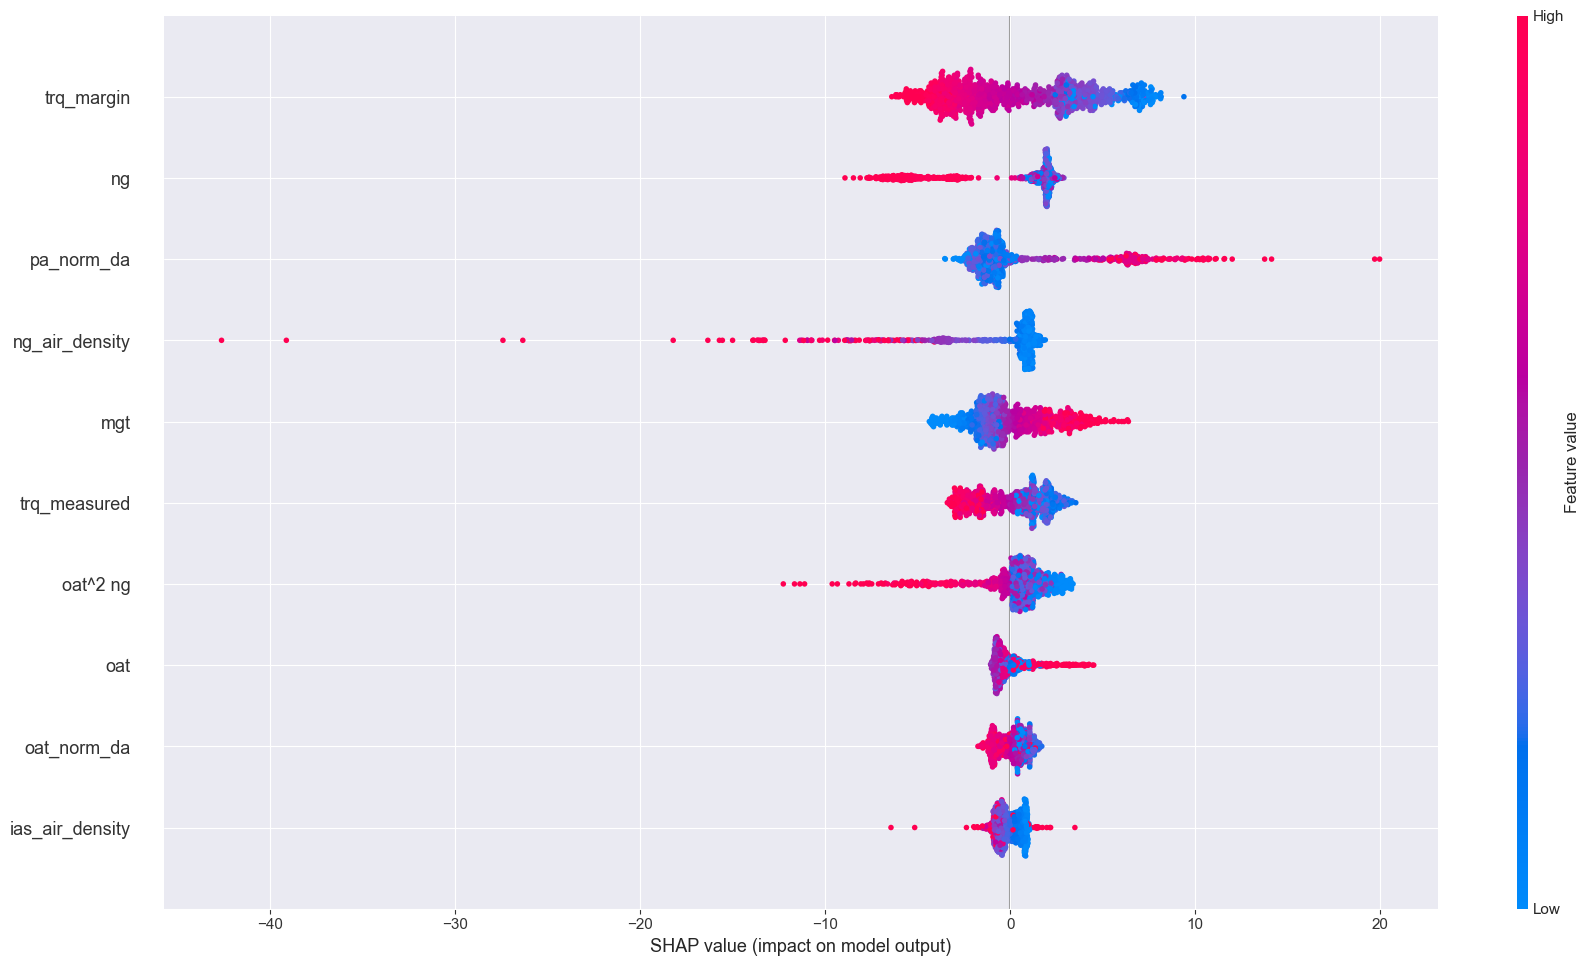

In [10]:
#4m 4s
explain_with_shap('fault_detection_train', trainset_x, samples=1_000)
# explain_with_shap('fault_detection_valid', validset_x, samples=1_000)
# explain_with_shap('fault_detection_test', testset_x, samples=1_000)